# FRBlip quick start

In [23]:
import numpy as np
import pymp
import frblip as frb
import matplotlib.pyplot as plt

## Create a mock of Cosmic Bursts

In [24]:
input_main_name = 'bingo'
input_array_name = 'naked_horn'
days = 30
zmax = 10
spectral_index = 0
seed = 42

telescopes = {}
telescopes['MAIN'] = frb.telescope(input_main_name)
telescopes['ARRAY'] = frb.telescope(input_array_name)

main_location = telescopes['MAIN'].location


mock = frb.blips(random_state=seed, duration=days, zmax=zmax, spectral_index=spectral_index)
mock.observe(telescopes, verbose=False, location=main_location)
mock.interferometry('MAIN', 'ARRAY', overwrite=True)
mock.interferometry('ARRAY', 'ARRAY', overwrite=True)

In [25]:
mock.redshift
mock.luminosity_distance
mock.igm_dm
mock.host_dm
mock.extra_galactic_dm
mock.__dict__.keys()

dict_keys(['duration', 'zmin', 'zmax', 'log_L0', 'log_Lstar', 'phistar', 'gamma', 'w_mean', 'w_std', '_spec_idx_dist', 'ra_range', 'dec_range', 'low_frequency', 'high_frequency', 'low_frequency_cal', 'high_frequency_cal', 'igm_model', 'free_electron_bias', 'cosmology', 'host_dist', 'host_source', 'host_model', 'emission_frame', 'start', 'gal_nside', 'gal_method', 'random_state', 'area', '_xmin', '_lumdist', '_cosmology', '_zdist', 'sky_rate', 'size', 'rate', 'params', 'spectral_index', 'redshift', 'luminosity_distance', 'log_luminosity', '_luminosity', 'flux', '_energy_normalization', 'observations', 'time', 'icrs', 'itrs', '_igm_dm', 'igm_dm', '_host_dm', 'host_dm', 'extra_galactic_dm'])

In [26]:
"""mock.observe(telescopes, verbose=False)
mock.interferometry('MAIN', 'ARRAY')"""

"mock.observe(telescopes, verbose=False)\nmock.interferometry('MAIN', 'ARRAY')"

The results are storage on observations property:

In [27]:
mock.observations

{'MAIN': <frblip.observation.Observation at 0x7fb80ae07f70>,
 'ARRAY': <frblip.observation.Observation at 0x7fb80ab32020>,
 'INTF_MAIN_ARRAY': <frblip.observation.Interferometry at 0x7fb80ab30700>,
 'INTF_ARRAY_ARRAY': <frblip.observation.Interferometry at 0x7fb80635b010>}

Computing signal to noise ratio:

To compute the total value over beams we pass True to the `total` argument

In [28]:
mock.signal_to_noise(total=True, todense=True)

{'MAIN': <xarray.DataArray (FRB: 2686380)> Size: 21MB
 array([0., 0., 0., ..., 0., 0., 0.])
 Dimensions without coordinates: FRB,
 'ARRAY': <xarray.DataArray (FRB: 2686380)> Size: 21MB
 array([0., 0., 0., ..., 0., 0., 0.])
 Dimensions without coordinates: FRB,
 'INTF_MAIN_ARRAY': <xarray.DataArray (FRB: 2686380)> Size: 21MB
 array([0., 0., 0., ..., 0., 0., 0.])
 Dimensions without coordinates: FRB,
 'INTF_ARRAY_ARRAY': <xarray.DataArray (FRB: 2686380)> Size: 21MB
 array([0., 0., 0., ..., 0., 0., 0.])
 Dimensions without coordinates: FRB}

The function `triggers` returns if a FRB is observed given minima signal to noise values, default value is range(1, 11):

In [29]:
mock.triggers(todense=True, total=True, snr=range(5, 16))

{'MAIN': <xarray.DataArray (FRB: 2686380, SNR: 11)> Size: 30MB
 array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]])
 Coordinates:
   * SNR      (SNR) int64 88B 5 6 7 8 9 10 11 12 13 14 15
 Dimensions without coordinates: FRB,
 'ARRAY': <xarray.DataArray (FRB: 2686380, SNR: 11)> Size: 30MB
 array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]])
 Coordinates:
   * SNR      (SNR) int64 88B 5 6 7 8

`counts` method returns the number of observed FRB:

In [30]:
mock.counts(total=True, snr=range(5, 16))

{'MAIN': <xarray.DataArray (SNR: 11)> Size: 88B
 array([13,  9,  9,  7,  7,  7,  7,  7,  5,  5,  5])
 Coordinates:
   * SNR      (SNR) int64 88B 5 6 7 8 9 10 11 12 13 14 15,
 'ARRAY': <xarray.DataArray (SNR: 11)> Size: 88B
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
 Coordinates:
   * SNR      (SNR) int64 88B 5 6 7 8 9 10 11 12 13 14 15,
 'INTF_MAIN_ARRAY': <xarray.DataArray (SNR: 11)> Size: 88B
 array([2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0])
 Coordinates:
   * SNR      (SNR) int64 88B 5 6 7 8 9 10 11 12 13 14 15,
 'INTF_ARRAY_ARRAY': <xarray.DataArray (SNR: 11)> Size: 88B
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
 Coordinates:
   * SNR      (SNR) int64 88B 5 6 7 8 9 10 11 12 13 14 15}

In [31]:
frb_data = mock.catalog()

In [43]:
len(frb_data['igm_dm'])

41

In [33]:
z = frb_data['redshift']
DM_IGM = frb_data['igm_dm']
DM_EG = frb_data['extra_galactic_dm']
DM_HG = frb_data['host_dm']

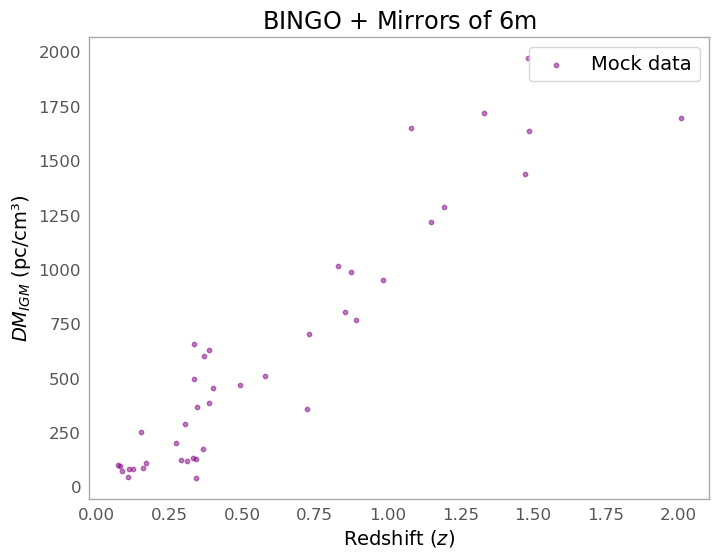

In [34]:
# Plot para o DM_IGM
plt.figure(figsize=(8, 6))
plt.scatter(z, DM_IGM, color='purple', alpha=0.5, label='Mock data', marker='o', s=10)
plt.xlabel('Redshift ($z$)', fontsize=14)
plt.ylabel('$DM_{IGM}$ (pc/cm³)', fontsize=14)
plt.title(label='BINGO $+$ Mirrors of 6m')
plt.legend(fontsize=14)
#plt.xlim(xmax=1)
#plt.ylim(ymax=1500)
plt.grid(False)
#plt.savefig('mock_DM_IGM_bingo+mirror_6m.png', dpi=600)
plt.show()

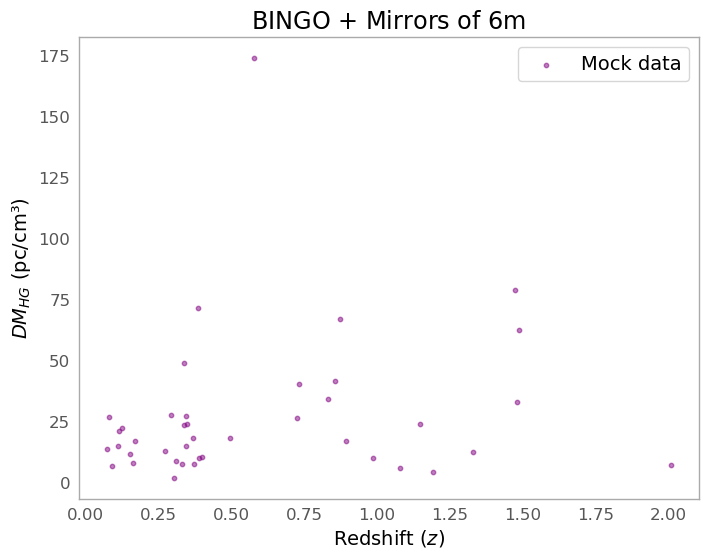

In [35]:
# Plot para o DM_HG
plt.figure(figsize=(8, 6))
plt.scatter(z, DM_HG, color='purple', alpha=0.5, label='Mock data', marker='o', s=10)
plt.xlabel('Redshift ($z$)', fontsize=14)
plt.ylabel('$DM_{HG}$ (pc/cm³)', fontsize=14)
plt.title(label='BINGO $+$ Mirrors of 6m')
plt.legend(fontsize=14)
#plt.xlim(xmax=1)
#plt.ylim(ymax=1500)
plt.grid(False)
#plt.savefig('mock_DM_HG_bingo+mirror_6m.png', dpi=600)
plt.show()

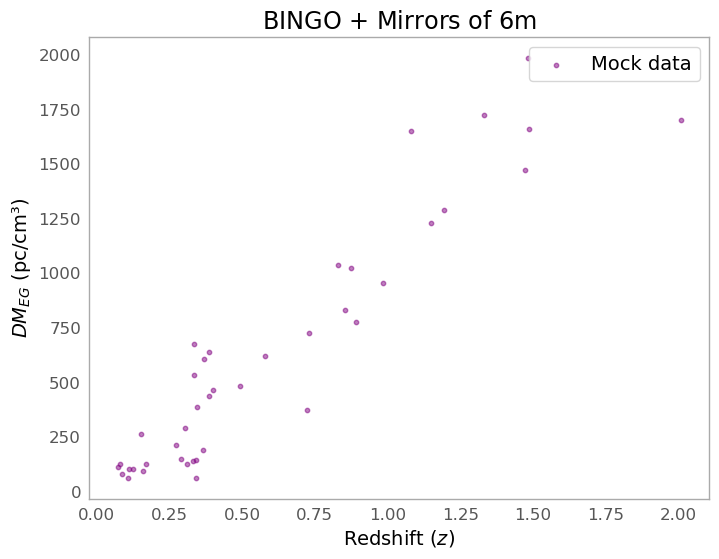

In [36]:
# Plot para o DM_EG
plt.figure(figsize=(8, 6))
plt.scatter(z, DM_EG, color='purple', alpha=0.5, label='Mock data', marker='o', s=10)
plt.xlabel('Redshift ($z$)', fontsize=14)
plt.ylabel('$DM_{EG}$ (pc/cm³)', fontsize=14)
plt.title(label='BINGO $+$ Mirrors of 6m')
plt.legend(fontsize=14)
#plt.xlim(xmax=1)
#plt.ylim(ymax=1500)
plt.grid(False)
#plt.savefig('mock_DM_EG_bingo+mirror_6m.png', dpi=600)
plt.show()

In [37]:
# Salvando os dados da DM_IGM

# Removendo as unidades
DM_IGM_value = DM_IGM.to_value()  

# Combinando os arrays em duas colunas
data = np.column_stack((z, DM_IGM_value))
#np.savetxt('data_sim/DM_IGM_sim_bingo+mirror_6m.txt', data, fmt='%f', delimiter='\t', header='z\tDM_IGM')

In [38]:
# Salvando os dados da DM_EG
DM_EG_value = DM_EG.to_value()  
data = np.column_stack((z, DM_EG_value))
#np.savetxt('data_sim/DM_EG_sim_bingo+mirror_6m.txt', data, fmt='%f', delimiter='\t', header='z\tDM_EG')

In [39]:
# Salvando os dados da DM_HG
DM_EG_value = DM_HG.to_value() 
data = np.column_stack((z, DM_EG_value))
#np.savetxt('data_sim/DM_HG_sim_bingo+mirror_6m.txt', data, fmt='%f', delimiter='\t', header='z\tDM_HG')

In [40]:
from astropy.coordinates import SkyCoord
from astropy.visualization import astropy_mpl_style
import astropy.units as u

plt.style.use(astropy_mpl_style)


In [41]:
declination = frb_data['declination']
right_ascension = frb_data['right_ascension']

coords = SkyCoord(ra=right_ascension, dec=declination, frame='icrs')


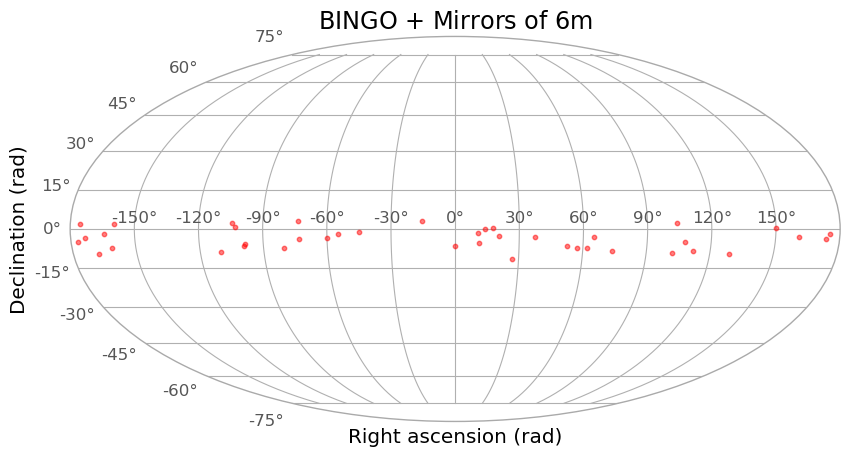

In [42]:
plt.figure(figsize=(10, 5))
plt.subplot(111, projection="mollweide")

# Converter RA para radianos e ajustar para o formato da projeção
ra_rad = coords.ra.wrap_at(180 * u.deg).radian
dec_rad = coords.dec.radian

plt.scatter(ra_rad, dec_rad, color='red', marker='o', s=10, alpha=0.5)
plt.grid(True)

plt.xlabel('Right ascension (rad)')
plt.ylabel('Declination (rad)')
plt.title(label='BINGO $+$ Mirrors of 6m')
#plt.savefig('sky_map_bingo+mirror_6m.png', dpi=600)
plt.show()